In [56]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [57]:
df = pd.read_csv("mes_donnees_normalisées.csv", sep=';')
df.head()

,essai,P6_reel,E1,V,E2,P1_reel,Lq1_reel,Lq2_reel,Lq_reel,Lq_target_x,...,P2,Lt,Lq_target_y,P3,P4,P5,P6_target,moyenne_E2,S_moy,sigma_S
0,392291.0,3.2,0.508681,0.0,0.762007,0.531993,0.140432,0.086909,0.139073,0.105263,...,0.0,0.0,0.0,0.5,0.646018,0.0,0.0,NaN,0.458702,0.137857
1,392291.0,3.2,0.480526,0.0,0.599283,0.531993,0.063272,0.053905,0.056291,0.105263,...,0.0,0.0,0.0,0.5,0.646018,0.0,0.0,NaN,0.458702,0.137857
2,392291.0,3.2,0.528390,0.0,0.675269,0.531993,0.078704,0.042904,0.072848,0.105263,...,0.0,0.0,0.0,0.5,0.646018,0.0,0.0,NaN,0.458702,0.137857
3,392291.0,3.2,0.481933,0.0,0.620072,0.531993,0.109568,0.053905,0.089404,0.105263,...,0.0,0.0,0.0,0.5,0.646018,0.0,0.0,NaN,0.458702,0.137857
4,392291.0,3.2,0.535429,0.0,0.750538,0.531993,0.140432,0.086909,0.139073,0.105263,...,0.0,0.0,0.0,0.5,0.646018,0.0,0.0,0.059949,0.458702,0.137857


In [58]:
df_propre = df[['P1_reel', 'P2', 'Lt', 'Lq_reel','P4', 'P5', 'V', 'E2', 'P6_reel', 'E1']]
df_nan = df_propre.dropna()
X_nan = np.array(df_nan.drop(columns='E1'))
Y_nan = np.array(df_nan['E1'])
print(X_nan.shape)

(556, 9)


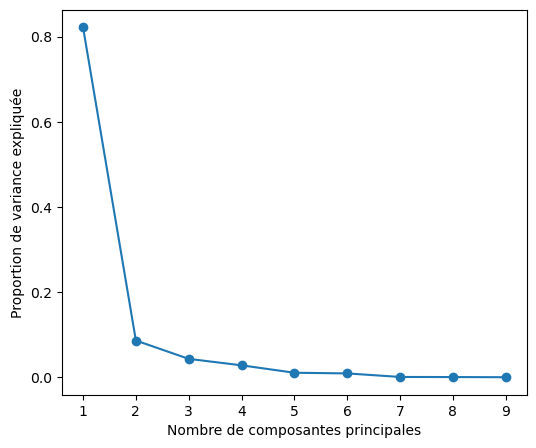

In [59]:
from sklearn import decomposition
pca = decomposition.PCA(n_components=9)
pca.fit(X_nan)

fig = plt.figure(figsize=(6, 5))

plt.plot(np.arange(1, 10), pca.explained_variance_ratio_, marker='o')

plt.xlabel("Nombre de composantes principales")
plt.ylabel("Proportion de variance expliquée")

plt.show()

[]

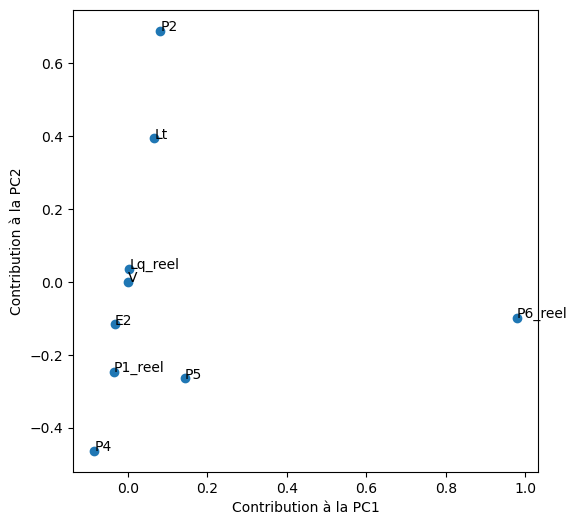

In [60]:
pcs = pca.components_
fig = plt.figure(figsize=(6, 6))

plt.scatter(pcs[0], pcs[1])
for (x_coordinate, y_coordinate, feature_name) in zip(pcs[0], pcs[1], df_propre.columns[:14]):
    plt.text(x_coordinate, y_coordinate, feature_name)                          
    
plt.xlabel("Contribution à la PC1")
plt.ylabel("Contribution à la PC2")

plt.plot()

In [61]:
from sklearn import preprocessing

polynomial_features = preprocessing.PolynomialFeatures(degree=3, include_bias=False)
from sklearn import model_selection
X_train, X_test, y_train, y_test = model_selection.train_test_split(X_nan, Y_nan, test_size=0.20, random_state=45)

X_train_poly = polynomial_features.fit_transform(X_train)

# Appliquer la même transformation aux données de test
X_test_poly = polynomial_features.transform(X_test)

print(X_train_poly.shape, X_test_poly.shape)

(444, 219) (112, 219)


In [62]:
from sklearn import linear_model
# Instancier une régression linéaire
polyreg = linear_model.LinearRegression()

# Entrainer cet objet sur les données d'entraînement
polyreg.fit(X_train_poly, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [63]:
from sklearn import metrics
linreg_rmse_train = metrics.root_mean_squared_error(y_train, polyreg.predict(X_train_poly))
print(f"RMSE de la régression linéaire sur le jeu d'entraînement : {linreg_rmse_train:.2f}.")
linreg_rmse_test = metrics.root_mean_squared_error(y_test, polyreg.predict(X_test_poly))
print(f"RMSE de la régression linéaire sur le jeu de test : {linreg_rmse_test:.2f}.")

RMSE de la régression linéaire sur le jeu d'entraînement : 0.04.
RMSE de la régression linéaire sur le jeu de test : 0.09.


In [64]:
polyreg_ridge = linear_model.Ridge(alpha=0.01)
polyreg_ridge.fit(X_train_poly, y_train)
polyreg_ridge_rmse_train = metrics.root_mean_squared_error(y_train, polyreg_ridge.predict(X_train_poly))
print(f"RMSE de la régression polynomiale sur le jeu d'entraînement : {polyreg_ridge_rmse_train:.2f}.")

polyreg_ridge_rmse_test = metrics.root_mean_squared_error(y_test, polyreg_ridge.predict(X_test_poly))
print(f"RMSE de la régression polynomiale sur le jeu de test : {polyreg_ridge_rmse_test:.2f}.")

RMSE de la régression polynomiale sur le jeu d'entraînement : 0.04.
RMSE de la régression polynomiale sur le jeu de test : 0.07.


In [65]:
df_2 = df_propre
df_2["P1_reel"] = df_propre["P1_reel"].fillna(df["P1_reel"].mean())
df_nan_2 = df_2.dropna()

X_nan_2 = np.array(df_nan_2.drop(columns='E1'))
X_test_poly_2 = polynomial_features.transform(X_nan_2)
y_test_2 = np.array(df_nan_2['E1'])

polyreg_ridge_rmse_test = metrics.root_mean_squared_error(y_test_2, polyreg_ridge.predict(X_test_poly_2))
print(f"RMSE de la régression polynomiale sur le jeu de test : {polyreg_ridge_rmse_test:.2f}.")

RMSE de la régression polynomiale sur le jeu de test : 0.15.


In [66]:
##test 3
df_propre = df[['P1_reel', 'P2', 'Lt', 'Lq_reel','P4', 'P5', 'V', 'E2', 'P6_reel', 'S_moy', 'sigma_S']]
df_nan = df_propre.dropna()
X_nan = np.array(df_nan.drop(columns=['S_moy', 'sigma_S']))
Y_nan = np.array(df_nan['S_moy'])
print(X_nan.shape)

polynomial_features = preprocessing.PolynomialFeatures(degree=3, include_bias=False)
from sklearn import model_selection
X_train, X_test, y_train, y_test = model_selection.train_test_split(X_nan, Y_nan, test_size=0.20, random_state=45)

X_train_poly = polynomial_features.fit_transform(X_train)

# Appliquer la même transformation aux données de test
X_test_poly = polynomial_features.transform(X_test)

print(X_train_poly.shape, X_test_poly.shape)

polyreg_ridge = linear_model.Ridge(alpha=0.01)
polyreg_ridge.fit(X_train_poly, y_train)
polyreg_ridge_rmse_train = metrics.root_mean_squared_error(y_train, polyreg_ridge.predict(X_train_poly))
print(f"RMSE de la régression polynomiale sur le jeu d'entraînement : {polyreg_ridge_rmse_train:.2f}.")

polyreg_ridge_rmse_test = metrics.root_mean_squared_error(y_test, polyreg_ridge.predict(X_test_poly))
print(f"RMSE de la régression polynomiale sur le jeu de test : {polyreg_ridge_rmse_test:.2f}.")

(556, 9)
(444, 219) (112, 219)
RMSE de la régression polynomiale sur le jeu d'entraînement : 0.06.
RMSE de la régression polynomiale sur le jeu de test : 0.07.


In [67]:
##test 2
df_propre = df[['P1_reel', 'P2', 'Lt', 'Lq_reel','P4', 'P5', 'V', 'E2', 'P6_reel', 'E1', 'moyenne_E2']]
df_nan = df_propre.dropna()
X_nan = np.array(df_nan.drop(columns=['moyenne_E2']))
Y_nan = np.array(df_nan['moyenne_E2'])
print(X_nan.shape)

polynomial_features = preprocessing.PolynomialFeatures(degree=3, include_bias=False)
from sklearn import model_selection
X_train, X_test, y_train, y_test = model_selection.train_test_split(X_nan, Y_nan, test_size=0.20, random_state=45)

X_train_poly = polynomial_features.fit_transform(X_train)

# Appliquer la même transformation aux données de test
X_test_poly = polynomial_features.transform(X_test)

print(X_train_poly.shape, X_test_poly.shape)

polyreg_ridge = linear_model.Ridge(alpha=0.01)
polyreg_ridge.fit(X_train_poly, y_train)
polyreg_ridge_rmse_train = metrics.root_mean_squared_error(y_train, polyreg_ridge.predict(X_train_poly))
print(f"RMSE de la régression polynomiale sur le jeu d'entraînement : {polyreg_ridge_rmse_train:.2f}.")

polyreg_ridge_rmse_test = metrics.root_mean_squared_error(y_test, polyreg_ridge.predict(X_test_poly))
print(f"RMSE de la régression polynomiale sur le jeu de test : {polyreg_ridge_rmse_test:.2f}.")

(278, 10)
(222, 285) (56, 285)
RMSE de la régression polynomiale sur le jeu d'entraînement : 0.04.
RMSE de la régression polynomiale sur le jeu de test : 0.05.


In [68]:
##test 3
df_propre = df[['P1_reel', 'P2', 'Lt', 'Lq_reel','P4', 'P5', 'V', 'E2', 'P6_reel', 'S_moy', 'sigma_S']]
df_nan = df_propre.dropna()
X_nan = np.array(df_nan.drop(columns=['S_moy', 'sigma_S']))
Y_nan = np.array(df_nan['sigma_S'])
print(X_nan.shape)

polynomial_features = preprocessing.PolynomialFeatures(degree=3, include_bias=False)
from sklearn import model_selection
X_train, X_test, y_train, y_test = model_selection.train_test_split(X_nan, Y_nan, test_size=0.20, random_state=45)

X_train_poly = polynomial_features.fit_transform(X_train)

# Appliquer la même transformation aux données de test
X_test_poly = polynomial_features.transform(X_test)

print(X_train_poly.shape, X_test_poly.shape)

polyreg_ridge = linear_model.Ridge(alpha=0.01)
polyreg_ridge.fit(X_train_poly, y_train)
polyreg_ridge_rmse_train = metrics.root_mean_squared_error(y_train, polyreg_ridge.predict(X_train_poly))
print(f"RMSE de la régression polynomiale sur le jeu d'entraînement : {polyreg_ridge_rmse_train:.2f}.")

polyreg_ridge_rmse_test = metrics.root_mean_squared_error(y_test, polyreg_ridge.predict(X_test_poly))
print(f"RMSE de la régression polynomiale sur le jeu de test : {polyreg_ridge_rmse_test:.2f}.")

(556, 9)
(444, 219) (112, 219)
RMSE de la régression polynomiale sur le jeu d'entraînement : 0.07.
RMSE de la régression polynomiale sur le jeu de test : 0.08.
